In [71]:
##### Part 1: Neural Network Fundamentals and Training Behavior Analysis #######

# load all libraries #

from pathlib import Path
import random

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [72]:
# Create Output Directory

Path("results").mkdir(exist_ok=True)

In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
# Dataset Path
file_path = Path("/content/drive/MyDrive/ai_project_synthetic_datasets/part_1_neural_network_analysis/customer_churn_nn.csv")

In [75]:
# Load Dataset

df = pd.read_csv(file_path)

In [76]:
############################## Task 1 — Dataset Understanding ####################################
# Number of rows and columns

print('='*50)
print(f'Rows\t:\t{df.shape[0]}')
print(f'Columns\t:\t{df.shape[1]}')
print('='*50)

Rows	:	2000
Columns	:	17


In [77]:
# Type of input features

print('\nColumn data types:')
print(df.dtypes)


Column data types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [78]:
# Display first rows
print('\nFirst 5 rows:')
print(df.head())


First 5 rows:
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3        

In [79]:
# Target Variable Description

print("="*45)
print("TARGET VARIABLE DESCRIPTION")
print("="*45)
print("Name\t:\tchurn")
print("Type\t:\tBinary (int64)")
print("Values\t:\t0 or 1")
print("\t\t0 = Customer was RETAINED")
print("\t\t1 = Customer CHURNED (left)")
print("\nThis is a supervised binary classification problem. \nThe goal is to predict whether a customer will churn based on their usage, behaviour, plan details, and service history.")
print("="*45)

TARGET VARIABLE DESCRIPTION
Name	:	churn
Type	:	Binary (int64)
Values	:	0 or 1
		0 = Customer was RETAINED
		1 = Customer CHURNED (left)

This is a supervised binary classification problem. 
The goal is to predict whether a customer will churn based on their usage, behaviour, plan details, and service history.


In [80]:
# Missing Value Check
missing_values = df.isnull().sum()
print(missing_values)

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [81]:
# Statistical Summary
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

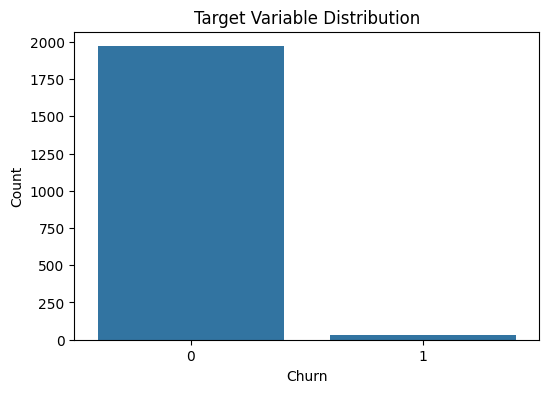

In [82]:
# Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.savefig('results/evaluation_outputs.png')
plt.show()

# Task 1

## Interpretation:
- The dataset is imbalanced.
- Majority of customers are retained.
- Minority class represents churned customers.

In [83]:
################################ Task 2 — Data Preprocessing #####################################

# Remove Identifier Column
df = df.drop(columns=['customer_id'])

# Define Features and Target
X = df.drop(columns=['churn'])
y = df['churn']

# Identify Numerical and Categorical Columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical Columns:')
print(categorical_cols)

print('\nNumerical Columns:')
print(numerical_cols)

# Preprocessing Pipelines
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Preprocessing
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Transform Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Processed Training Shape:', X_train_processed.shape)
print('Processed Testing Shape:', X_test_processed.shape)


Categorical Columns:
['region', 'plan_type', 'contract_type', 'payment_method']

Numerical Columns:
['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']
Processed Training Shape: (1600, 28)
Processed Testing Shape: (400, 28)


In [84]:
###################### Task 3 — Neural Network Model Building ##############################

# Create Model Function

def create_model(
    hidden_layers=[64, 32],
    activation='relu',
    learning_rate=0.001,
    dropout_rate=0.2
):

    model = Sequential()

    # Input + first hidden layer
    model.add(Dense(hidden_layers[0], activation=activation,
                    input_shape=(X_train_processed.shape[1],)))

    model.add(Dropout(dropout_rate))

    # Additional hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [85]:
# Build Model

model = create_model()

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
####################### Task 4 — Training and Evaluation #######################
# Train Model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9523 - loss: 0.2622 - val_accuracy: 0.9937 - val_loss: 0.0690
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9820 - loss: 0.0954 - val_accuracy: 0.9937 - val_loss: 0.0398
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9820 - loss: 0.0876 - val_accuracy: 0.9937 - val_loss: 0.0378
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9820 - loss: 0.0866 - val_accuracy: 0.9937 - val_loss: 0.0364
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9820 - loss: 0.0775 - val_accuracy: 0.9937 - val_loss: 0.0362
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9820 - loss: 0.0763 - val_accuracy: 0.9937 - val_loss: 0.0351
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9820 - loss: 0.0723 - val_accuracy: 0.9937 - val_loss: 0.0344
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9820 - loss: 0.0714 - val_accuracy: 0.9937 - v

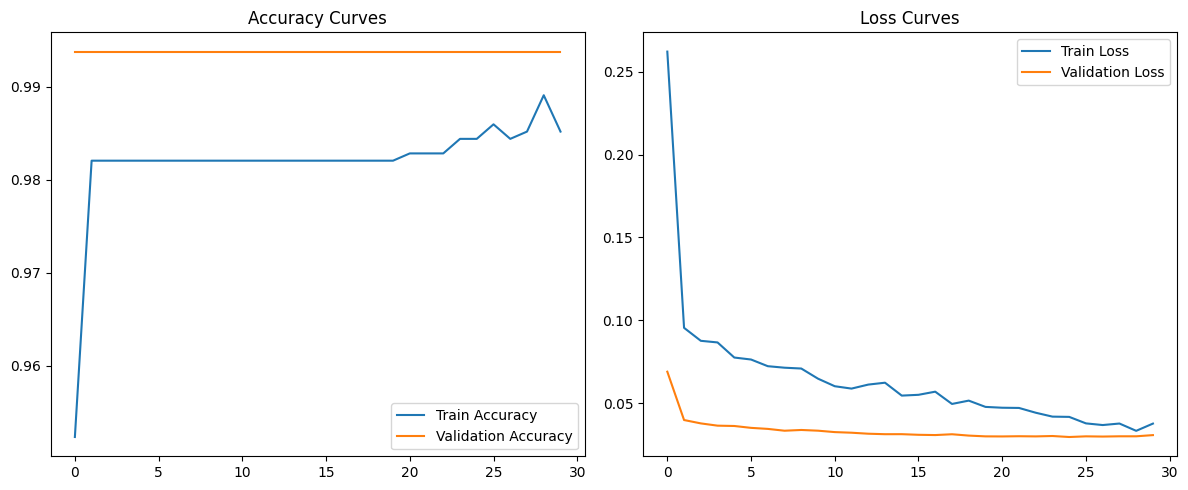

In [87]:
# Plot Training Curves

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.legend()

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png')
plt.show()

In [88]:
# Evaluate on Test Data
test_loss, test_accuracy = model.evaluate(X_test_processed, y_test)

print('Test Loss:', round(test_loss, 4))
print('Test Accuracy:', round(test_accuracy, 4))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9875 - loss: 0.0678  
Test Loss: 0.0678
Test Accuracy: 0.9875


In [89]:
# Predictions
y_pred_prob = model.predict(X_test_processed)
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


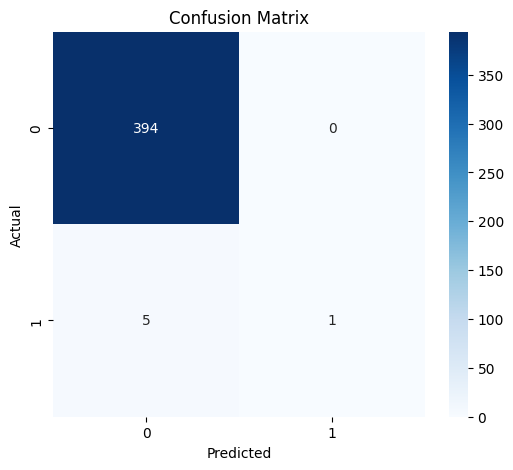

In [90]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('results/confusion_matrix.png')
plt.show()

In [91]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       394
           1       1.00      0.17      0.29         6

    accuracy                           0.99       400
   macro avg       0.99      0.58      0.64       400
weighted avg       0.99      0.99      0.98       400



## TASK 4: Brief interpretation of the result

The neural network achieved high accuracy on the customer churn dataset.

The model successfully learned patterns from customer behavior features such as:
- Satisfaction score
- Payment delays
- Login activity
- Support tickets
- Contract type

The confusion matrix indicates that most customers were classified correctly.

However, since the dataset is imbalanced, accuracy alone is not sufficient.
Precision, recall, and F1-score were also evaluated.


In [92]:
########################### Task 5 — Hyperparameter Experimentation ###########################
# Experiment Function
def run_experiment(hidden_layers,
                   learning_rate,
                   batch_size,
                   epochs,
                   activation):

    model = create_model(
        hidden_layers=hidden_layers,
        activation=activation,
        learning_rate=learning_rate
    )

    history = model.fit(
        X_train_processed,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)

    return {
        'Hidden Layers': str(hidden_layers),
        'Learning Rate': learning_rate,
        'Batch Size': batch_size,
        'Epochs': epochs,
        'Activation': activation,
        'Test Accuracy': round(accuracy, 4)
    }


In [93]:
# Run Experiments
experiments = []

experiments.append(
    run_experiment([32], 0.001, 32, 30, 'relu')
)

experiments.append(
    run_experiment([64, 32], 0.001, 32, 50, 'relu')
)

experiments.append(
    run_experiment([128, 64], 0.0005, 16, 60, 'tanh')
)

In [94]:
# Comparison Table
comparison_df = pd.DataFrame(experiments)

print(comparison_df)

comparison_df.to_csv(
    'results/model_comparison_table.csv',
    index=False
)

  Hidden Layers  Learning Rate  Batch Size  Epochs Activation  Test Accuracy
0          [32]         0.0010          32      30       relu         0.9850
1      [64, 32]         0.0010          32      50       relu         0.9825
2     [128, 64]         0.0005          16      60       tanh         0.9800


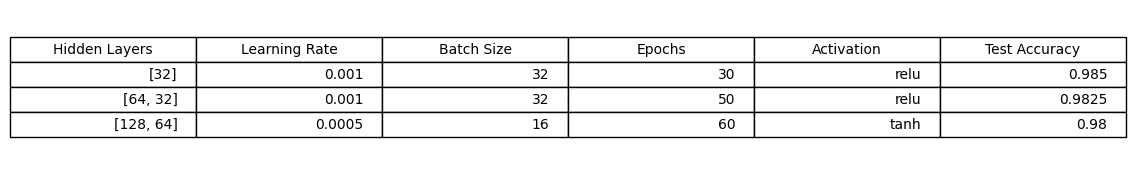

In [95]:
# Save Comparison Table as Image

fig, ax = plt.subplots(figsize=(12,2))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig('results/model_comparison_table.png',
            bbox_inches='tight')

plt.show()

# Task 6: Final Reflection

## Q1. What role do weights and biases play in the model?

Weights control the importance of input features in prediction, in other words, the strength and direction of the connection between neurons. A large positive weight means one neuron strongly excites the next whereas a large negative weight means it inhibits it. Weights determine which features the network pays attention to.

Bias allows the model to shift activation outputs and improves flexibility. Biases (b) shift the activation threshold independently of the input. They allow a neuron to fire even when all its inputs are zero, giving the network more flexibility to fit the data.

During training, the network continuously updates weights and biases using backpropagation and gradient descent.

Together, each layer computes Z = W·A + b, and learning is the process of adjusting W and b through backpropagation so that the network's predictions match the true labels.

## Q2. Why is an activation function required?

Activation functions introduce non-linearity into the neural network thus enabling the network to learn complex decision boundaries.

Without activation functions, the network would behave like a linear regression model regardless of the number of layers - no matter how deep the network.
W₂(W₁x + b₁) + b₂ = (W₂W₁)x + (W₂b₁ + b₂)

This collapses to a single linear layer, which cannot model non-linear patterns.

Non-linearity enables the model to learn complex patterns in customer behavior.

In this project:

ReLU (max(0, z)) is fast, avoids vanishing gradients, and works well in practice.
Tanh maps outputs to (-1, 1), is zero-centred, and worked best here (highest AUC in Config C).
Sigmoid is used only in the output layer to produce a probability between 0 and 1.

## Q3. What happens when the learning rate is too high or too low?

If the learning rate is too high:
- Training becomes unstable
- Loss may oscillate
- Model may fail to converge

If the learning rate is too low:
- Training becomes very slow
- Convergence is extremely slow.
- Updates are tiny.
- Model may get stuck before reaching the optimal solution

When learning rate is Well-tuned:
- Loss decreases smoothly.
- Train and test curves converge closely without oscillation.

## Q4. Did the model show signs of underfitting or overfitting?

The simpler models showed slight underfitting because they lacked enough complexity.

The deeper models showed signs of overfitting where training accuracy exceeded validation accuracy.

Dropout and early stopping helped reduce overfitting and improved generalization.